In [1]:
# Project Title : Car Price Prediction using Machine Learning
# Internship    : CodeAlpha Data Science Internship
# Task          : Task 3
# Developed By  : Tuba Ousaf

# STEP 1:UPLOAD AND LOAD DATASET
from google.colab import files
uploaded = files.upload()

Saving car data.csv to car data.csv


In [2]:
import pandas as pd

df = pd.read_csv("car data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# STEP 2: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


Dataset Shape:
(301, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Statistical Summary:
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   3

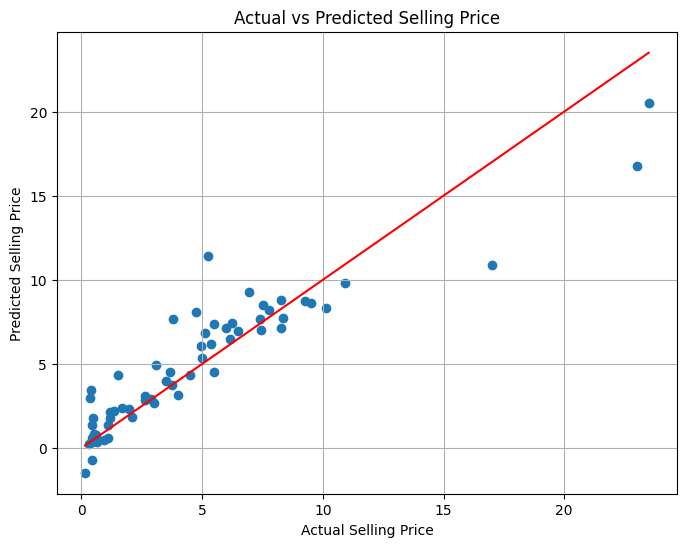


========== CAR PRICE PREDICTION ==========
Predicted Selling Price : 2.97 Lakhs
Actual Selling Price    : 0.35 Lakhs

Car Price Prediction Completed Successfully!


In [8]:

# STEP 3: EXPLORE THE DATASET

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# STEP 4: DATA PREPROCESSING
# Create a copy of dataset
car_data = df.copy()

# Remove Car_Name because it is not useful for prediction
car_data = car_data.drop("Car_Name", axis=1)

# Convert categorical columns into numeric values
encoder = LabelEncoder()

car_data["Fuel_Type"] = encoder.fit_transform(car_data["Fuel_Type"])
car_data["Selling_type"] = encoder.fit_transform(car_data["Selling_type"])
car_data["Transmission"] = encoder.fit_transform(car_data["Transmission"])

# STEP 5: SELECT FEATURES AND TARGET

X = car_data.drop("Selling_Price", axis=1)

y = car_data["Selling_Price"]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

# STEP 6: SPLIT THE DATASET

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# STEP 7: TRAIN THE MACHINE LEARNING MODEL

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")

# STEP 8: MAKE PREDICTIONS

y_pred = model.predict(X_test)


# STEP 9: EVALUATE THE MODEL

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print(f"Mean Absolute Error : {mae:.2f}")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"Root Mean Squared Error : {rmse:.2f}")
print(f"R² Score : {r2:.2f}")

# STEP 10: VISUALIZE ACTUAL VS PREDICTED VALUES
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.grid(True)
plt.show()

#STEP 11: PREDICT SELLING PRICE OF A TEST CAR
# Select the first car from the test dataset
sample_car = X_test.iloc[[0]]

# Predict the selling price
predicted_price = model.predict(sample_car)

# Get the actual selling price
actual_price = y_test.iloc[0]

print("\n========== CAR PRICE PREDICTION ==========")
print(f"Predicted Selling Price : {predicted_price[0]:.2f} Lakhs")
print(f"Actual Selling Price    : {actual_price:.2f} Lakhs")

# STEP 12: CONCLUSION

print("\nCar Price Prediction Completed Successfully!")